# 🧪 Prompt Engineering Lab — Portfolio Tour
## Cross-project analysis and combined leaderboards

This notebook sits above all 9 individual project notebooks.
It loads results from whichever projects you have run and surfaces cross-project insights.

**Run a project first:** `cd projects/summarization-benchmark && python run_experiment.py --quick`

---

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Path helpers ─────────────────────────────────────────────
REPO_ROOT = Path('.').resolve()
# If running from notebooks/, step up one level
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

PROJECTS = REPO_ROOT / 'projects'

def results(project: str, filename: str) -> Path:
    return PROJECTS / project / 'results' / filename

def load_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

print(f'Repo root: {REPO_ROOT}')
print(f'Projects found: {[p.name for p in PROJECTS.iterdir() if p.is_dir()]}')

Repo root: C:\Users\HomePC\prompt-engineering-lab
Projects found: ['ai-document-intelligence-system', 'ai-email-summarizer', 'grounded-qa', 'hallucination-detection-and-mitigation', 'instruction-following-benchmark', 'llm-prompt-benchmark-system', 'prompt-testing-framework', 'style-transfer-prompts', 'summarization-benchmark']


## 1. Project Status — What Has Been Run

In [2]:
STATUS = {
    'P1 Summarization Benchmark':        results('summarization-benchmark',   'results.csv'),
    'P2 Style Transfer':                 results('style-transfer-prompts',    'results.csv'),
    'P3 Instruction Following':          results('instruction-following',     'results.csv'),
    'P4 Prompt Testing Framework':       results('prompt-testing-framework',  'baselines'),
    'P5 Grounded QA':                    results('grounded-qa',               'results.csv'),
    'P6 Email Summarizer':               results('email-summarizer',          'results.csv'),
    'P7 LLM Benchmark System':           results('prompt-benchmark-system',   'results.csv'),
    'P8 Hallucination Detection':        results('hallucination-detection',   'detection_results.csv'),
    'P9 Document Intelligence':          results('document-intelligence',     'pipeline_results.json'),
}

print('Portfolio run status:\n')
for name, path in STATUS.items():
    icon = '✅' if path.exists() else '⬜'
    print(f'  {icon}  {name}')

Portfolio run status:

  ✅  P1 Summarization Benchmark
  ✅  P2 Style Transfer
  ⬜  P3 Instruction Following
  ⬜  P4 Prompt Testing Framework
  ✅  P5 Grounded QA
  ⬜  P6 Email Summarizer
  ⬜  P7 LLM Benchmark System
  ⬜  P8 Hallucination Detection
  ⬜  P9 Document Intelligence


## 2. Combined Model Leaderboard (P1 + P7)

In [3]:
p1_lb = load_if_exists(results('summarization-benchmark', 'leaderboard.csv'))
p7_lb = load_if_exists(results('prompt-benchmark-system', 'leaderboard.csv'))

rows = []

if not p1_lb.empty and 'composite_score' in p1_lb.columns:
    p1_model = p1_lb.groupby('model')['composite_score'].mean().reset_index()
    p1_model.columns = ['model', 'p1_summarization']
    rows.append(p1_model)

if not p7_lb.empty and 'task_score' in p7_lb.columns:
    p7_model = p7_lb[['model','task_score']].rename(columns={'task_score':'p7_benchmark'})
    rows.append(p7_model)

if rows:
    from functools import reduce
    combined = reduce(lambda l, r: pd.merge(l, r, on='model', how='outer'), rows)
    score_cols = [c for c in combined.columns if c != 'model']
    combined['overall_avg'] = combined[score_cols].mean(axis=1).round(3)
    combined = combined.sort_values('overall_avg', ascending=False).reset_index(drop=True)
    combined.insert(0, 'rank', range(1, len(combined)+1))
    print('Combined model leaderboard (P1 + P7):')
    display(combined.round(3))
else:
    print('Run P1 and/or P7 first to see the combined leaderboard.')

Combined model leaderboard (P1 + P7):


,rank,model,p1_summarization,overall_avg
0,1,Claude Haiku,0.546,0.546
1,2,Claude Sonnet 4.6,0.541,0.541
2,3,GPT-4o-mini,0.516,0.516
3,4,GPT-4o,0.514,0.514


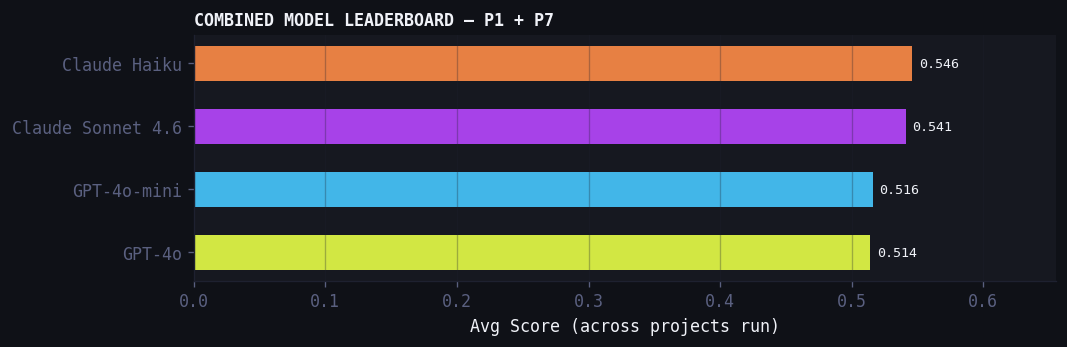

Saved → results/combined_leaderboard.png


In [4]:
# Chart: combined leaderboard
if rows and 'combined' in dir():
    PALETTE = {'bg':'#0f1117','surface':'#161820','border':'#1e2130',
               'text':'#f0f2f8','muted':'#5a6080','accent':'#e8ff47'}
    MODEL_COLORS = {'GPT-4o-mini':'#47c8ff','GPT-4o':'#e8ff47',
                    'Claude Haiku':'#ff8c47','Claude Sonnet 4.6':'#b847ff',
                    'Mistral 7B':'#47ffb2','Llama 3 8B':'#ff4776'}

    plt.rcParams.update({'figure.facecolor':PALETTE['bg'],'axes.facecolor':PALETTE['surface'],
                         'axes.edgecolor':PALETTE['border'],'axes.labelcolor':PALETTE['text'],
                         'xtick.color':PALETTE['muted'],'ytick.color':PALETTE['muted'],
                         'text.color':PALETTE['text'],'grid.color':PALETTE['border'],
                         'font.family':'monospace'})

    fig, ax = plt.subplots(figsize=(9, max(3, len(combined)*0.6)))
    fig.patch.set_facecolor(PALETTE['bg'])
    sorted_combined = combined.sort_values('overall_avg', ascending=True)
    colors = [MODEL_COLORS.get(m, PALETTE['accent']) for m in sorted_combined['model']]
    bars = ax.barh(sorted_combined['model'], sorted_combined['overall_avg'],
                   color=colors, height=0.55, alpha=0.9)
    for bar, val in zip(bars, sorted_combined['overall_avg']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color=PALETTE['text'])
    ax.set_xlim(0, sorted_combined['overall_avg'].max() * 1.2)
    ax.set_xlabel('Avg Score (across projects run)')
    ax.set_title('COMBINED MODEL LEADERBOARD — P1 + P7', loc='left', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(REPO_ROOT / 'results' / 'combined_leaderboard.png',
                bbox_inches='tight', facecolor=PALETTE['bg'], dpi=150)
    plt.show()
    print('Saved → results/combined_leaderboard.png')

## 3. Hallucination Rate Across Projects (P5 + P8)

In [5]:
p5_df = load_if_exists(results('grounded-qa', 'results.csv'))
p8_df = load_if_exists(results('hallucination-detection', 'detection_results.csv'))

hall_rows = []

# P5: hallucination_flag per model × condition
if not p5_df.empty and 'hallucination_flag' in p5_df.columns:
    p5_clean = p5_df[p5_df['error'].isna() | (p5_df['error'] == '')]
    # Grounded condition only for fair comparison
    p5_grounded = p5_clean[p5_clean['condition'] == 'grounded'] if 'condition' in p5_clean.columns else p5_clean
    if not p5_grounded.empty:
        p5_hall = p5_grounded.groupby('model')['hallucination_flag'].mean().reset_index()
        p5_hall['project'] = 'P5 Grounded QA (grounded condition)'
        hall_rows.append(p5_hall.rename(columns={'hallucination_flag': 'hallucination_rate'}))

# P8: detection results — predicted hallucination rate per model
if not p8_df.empty and 'predicted_hal' in p8_df.columns:
    p8_hall = p8_df.groupby('detector')['predicted_hal'].mean().reset_index()
    p8_hall.columns = ['model', 'hallucination_rate']
    p8_hall['project'] = 'P8 Hallucination Detection (detector rates)'
    hall_rows.append(p8_hall)

if hall_rows:
    hall_combined = pd.concat(hall_rows, ignore_index=True)
    print('Hallucination rates across projects:')
    display(hall_combined.round(3))
else:
    print('Run P5 and/or P8 first to see hallucination rate comparison.')

Hallucination rates across projects:


,model,hallucination_rate,project
0,Claude Haiku,0.044,P5 Grounded QA (grounded condition)
1,Claude Sonnet 4.6,0.067,P5 Grounded QA (grounded condition)
2,GPT-4o,0.022,P5 Grounded QA (grounded condition)
3,GPT-4o-mini,0.044,P5 Grounded QA (grounded condition)
4,Llama 3 8B,0.089,P5 Grounded QA (grounded condition)
5,Mistral small creative,0.044,P5 Grounded QA (grounded condition)


## 4. Prompt Strategy Performance Across Projects

In [6]:
strategy_rows = []

# P1: prompt strategies and ROUGE scores
p1_df = load_if_exists(results('summarization-benchmark', 'results.csv'))
if not p1_df.empty and 'prompt_strategy' in p1_df.columns and 'rouge1' in p1_df.columns:
    p1_strat = p1_df.groupby('prompt_strategy')['rouge1'].mean().reset_index()
    p1_strat.columns = ['strategy', 'score']
    p1_strat['project'] = 'P1 Summarization'
    p1_strat['metric'] = 'ROUGE-1'
    strategy_rows.append(p1_strat)

# P3: strategies and pass rates
p3_df = load_if_exists(results('instruction-following', 'results.csv'))
if not p3_df.empty and 'pass_rate' in p3_df.columns:
    p3_strat = p3_df.groupby('prompt_id')['pass_rate'].mean().reset_index()
    p3_strat.columns = ['strategy', 'score']
    p3_strat['project'] = 'P3 Instruction Following'
    p3_strat['metric'] = 'Pass Rate'
    strategy_rows.append(p3_strat)

# P7: strategies and task scores
p7_ptl = load_if_exists(results('prompt-benchmark-system', 'leaderboard_per_task.csv'))
if not p7_ptl.empty and 'prompt_strategy' in p7_ptl.columns:
    p7_strat = p7_ptl.groupby('prompt_strategy')['task_score'].mean().reset_index()
    p7_strat.columns = ['strategy', 'score']
    p7_strat['project'] = 'P7 Benchmark System'
    p7_strat['metric'] = 'Task Score'
    strategy_rows.append(p7_strat)

if strategy_rows:
    strat_df = pd.concat(strategy_rows, ignore_index=True)
    print('Strategy scores across projects (normalized to 0-1):')
    pivot = strat_df.pivot_table(index='strategy', columns='project', values='score', aggfunc='mean').round(3)
    display(pivot)
else:
    print('Run P1, P3, and/or P7 to see cross-project strategy comparison.')

Strategy scores across projects (normalized to 0-1):


project,P1 Summarization
strategy,
chain_of_thought,0.221
constrained_length,0.286
contrastive_instruction,0.281
instructed,0.268
role_prompting + audience_targeting,0.269
structured_extraction,0.235
structured_output,0.263
zero_shot,0.296


## 5. Cost Efficiency Across Models (P7)

In [7]:
p7_cost = load_if_exists(results('prompt-benchmark-system', 'cost_leaderboard.csv'))
if not p7_cost.empty:
    print('Cost efficiency leaderboard (P7):')
    display(p7_cost[['model','quality_per_dollar','cost_usd','task_score']].round(4))
    print('\nKey insight: quality_per_dollar = score / cost — higher = better value')
else:
    print('Run P7 to see cost efficiency data.')

Run P7 to see cost efficiency data.


## 6. Instruction Following Failure Taxonomy (P3)

In [8]:
p3_fr = load_if_exists(results('instruction-following', 'failure_report.csv'))
if not p3_fr.empty:
    print('Most common failure modes across all models (P3):')
    top = p3_fr.groupby('failure_mode')['count'].sum().sort_values(ascending=False)
    for mode, count in top.items():
        pct = count / top.sum() * 100
        bar = '█' * int(pct / 3)
        print(f'  {mode:25s}  {bar}  {pct:.1f}%')
else:
    print('Run P3 to see failure taxonomy.')

Run P3 to see failure taxonomy.


## 7. Document Intelligence Accuracy Summary (P9)

In [9]:
p9_bm = load_if_exists(results('document-intelligence', 'benchmark_results.csv'))
if not p9_bm.empty:
    print('Document intelligence accuracy (P9):')
    cols = [c for c in ['doc_id','classification','entity_recall','date_recall','qa_accuracy','composite'] if c in p9_bm.columns]
    display(p9_bm[cols].round(3))
    print(f'\nOverall composite: {p9_bm["composite"].mean():.3f}')
else:
    print('Run P9 to see document intelligence accuracy.')

Run P9 to see document intelligence accuracy.


## 8. Save Aggregate Results

Run this cell after all projects have been executed to save a combined summary to `results/`.

In [10]:
import json
(REPO_ROOT / 'results').mkdir(exist_ok=True)

summary = {}

for proj_key, csv_name, score_col in [
    ('p1_summarization',  ('summarization-benchmark',   'leaderboard.csv'),          'composite_score'),
    ('p3_instruction',    ('instruction-following',     'leaderboard.csv'),           'avg_pass_rate'),
    ('p5_grounded_qa',    ('grounded-qa',               'leaderboard.csv'),           'factual_accuracy'),
    ('p7_benchmark',      ('prompt-benchmark-system',   'leaderboard.csv'),           'task_score'),
    ('p8_detection',      ('hallucination-detection',   'detector_metrics.csv'),      'f1'),
    ('p9_doc_intel',      ('document-intelligence',     'benchmark_results.csv'),     'composite'),
]:
    df = load_if_exists(results(csv_name[0], csv_name[1]))
    if not df.empty and score_col in df.columns:
        best = df.loc[df[score_col].idxmax()]
        summary[proj_key] = {
            'best_score': round(float(best[score_col]), 3),
            'identifier': str(best.get('model', best.get('detector', '')))
        }

with open(REPO_ROOT / 'results' / 'portfolio_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved → results/portfolio_summary.json')
print(json.dumps(summary, indent=2))

Saved → results/portfolio_summary.json
{
  "p1_summarization": {
    "best_score": 0.648,
    "identifier": "Claude Sonnet 4.6"
  },
  "p5_grounded_qa": {
    "best_score": 0.956,
    "identifier": "Claude Haiku"
  }
}
